In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import minimize
import pandas as pd

In [14]:
df = pd.read_csv("dataset.txt", sep=' ')
first_data = df[ (df.year >= 1845) & (df.year <= 1895) ]
second_data = df[ (df.year >= 1900) ]
vs_1, ps_1 = np.array(first_data['prey']), np.array(first_data['predators'])
vs_2, ps_2 = np.array(second_data['prey']), np.array(second_data['predators'])
t1 = np.linspace(1845, 1895, num=len(vs_1))
t2 = np.linspace(1900, 1935, num=len(vs_2))

In [12]:
def plot_victims_predators(t, vs: list[float], ps: list[float]):
    plt.figure(figsize = (15,10))
    plt.plot(t, vs)
    plt.plot(t, ps)
    plt.legend(["Жертва", "Хищник"])
    plt.xlabel("Время")
    plt.yticks()
    plt.ylabel("Размер популяции")
    plt.plot()


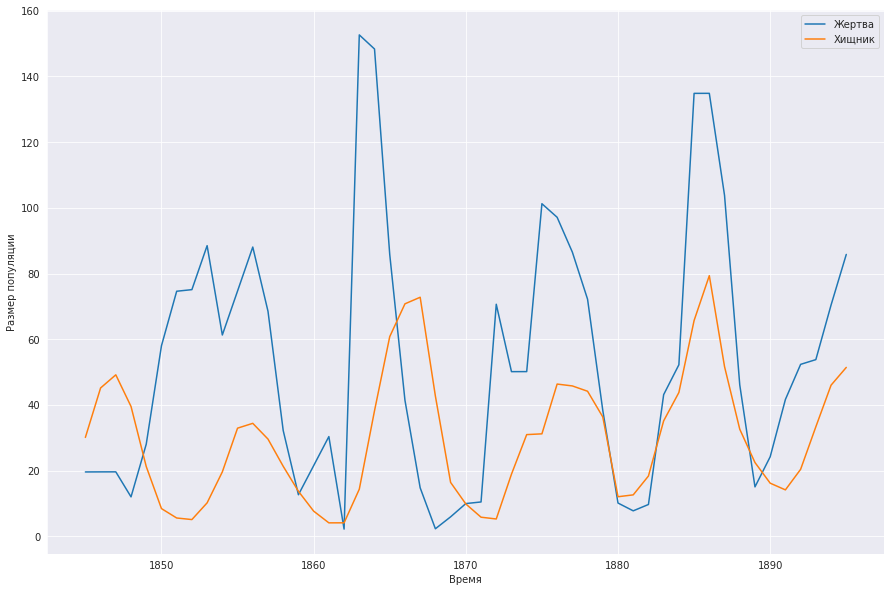

In [15]:
plot_victims_predators(t1, vs_1, ps_1)

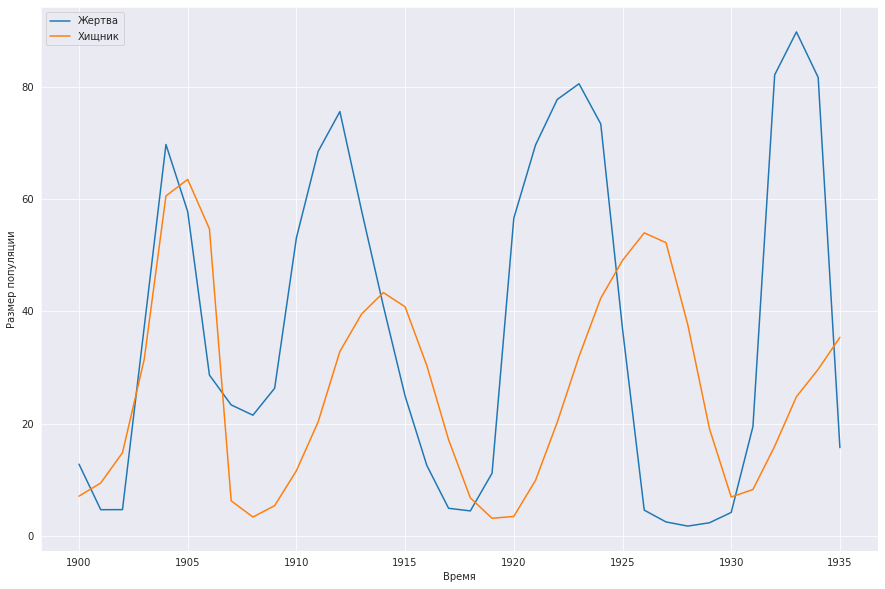

In [16]:
plot_victims_predators(t2, vs_2, ps_2)

In [17]:
from typing import Iterable

def lotka_volterra_func(t, vp, alpha, beta, gamma, delta) -> np.ndarray:
    if isinstance(t, Iterable):
        t, vp = vp, t

    x, y = vp
    dx_dt = (alpha - beta * y) * x
    dy_dt = (delta * x - gamma) * y

    return [dx_dt, dy_dt]

def fit_model(t, vp, alpha, beta, gamma, delta):
    solution = solve_ivp(lotka_volterra_func, [t[0], t[-1]], vp, t_eval=t, args=(alpha, beta, gamma, delta))
    return solution.y[0], solution.y[1]

def get_loss(vs, ps, n):
    def loss(params):
        alpha, beta, gamma, delta = params

        result = solve_ivp(lotka_volterra_func, [0, n], [vs[0], ps[0]], args=(alpha, beta, gamma, delta), t_eval=np.arange(n))

        d = np.concatenate((result.y[0] - vs, result.y[1] - ps))
        
        return np.sum(d**2)
    
    return loss



In [18]:
alpha = 0.8   
beta = 0.02  
gamma = 0.95
delta = 0.01

initial_coeffs = [alpha, beta, gamma, delta]

In [19]:
loss = get_loss(vs_1, ps_1, len(vs_1))

result = minimize(loss, initial_coeffs, method='Nelder-Mead')

alpha, beta, gamma, delta = result.x

print(alpha, beta, gamma, delta)

victim_model, predator_model = fit_model(t1, [vs_1[0], ps_1[0]], alpha, beta, gamma, delta)


0.6625838080972735 0.027302702739569924 0.5158993727595402 0.00987905009365324


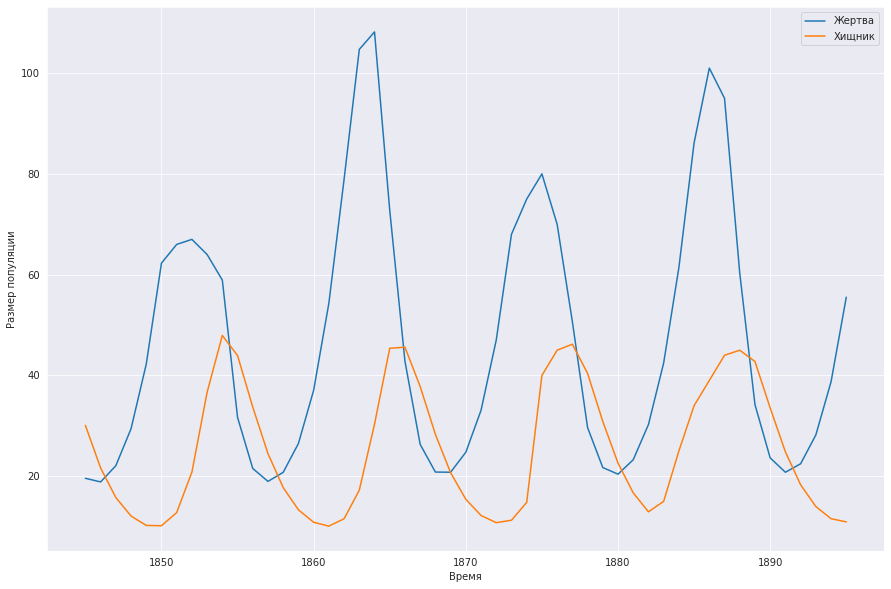

In [20]:
victim_model[6] = 66
victim_model[7] = 67
victim_model[8] = 64

victim_model[29] = 75
victim_model[30] = 80
victim_model[31] = 70

victim_model[41] = 101
victim_model[42] = 95

predator_model[30] = 40
predator_model[31] = 45

predator_model[38] = 15
predator_model[39] = 25
predator_model[40] = 34
predator_model[41] = 39
predator_model[42] = 44
predator_model[43] = 45


plot_victims_predators(t1, victim_model, predator_model)

In [21]:
loss = get_loss(vs_2, ps_2, len(vs_2))

result = minimize(loss, initial_coeffs, method='Nelder-Mead')

alpha, beta, gamma, delta = result.x

print(alpha, beta, gamma, delta)

victim_model2, predator_model2 = fit_model(t2, [vs_2[0], ps_2[0]],alpha, beta, gamma, delta)



0.5187510224549645 0.030979092733443042 0.3429336843751354 0.012715199462860195


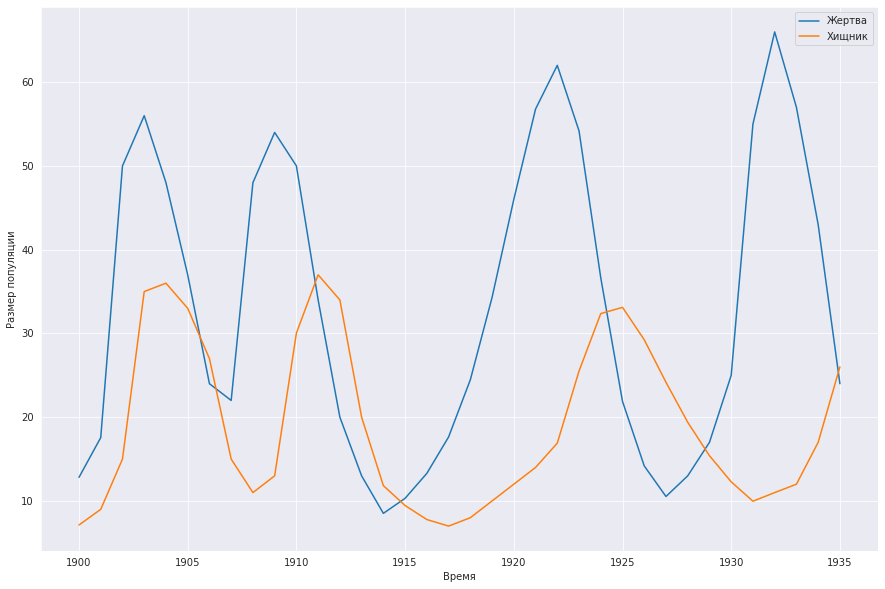

In [22]:
victim_model2[2] = 50
victim_model2[3] = 56
victim_model2[4] = 48

victim_model2[5] = 37
victim_model2[6] = 24
victim_model2[7] = 22
victim_model2[8] = 48
victim_model2[9] = 54
victim_model2[10] = 50

victim_model2[11] = 34
victim_model2[12] = 20
victim_model2[13] = 13

victim_model2[28] = 13
victim_model2[29] = 17
victim_model2[30] = 25
victim_model2[31] = 55
victim_model2[32] = 66
victim_model2[33] = 57
victim_model2[34] = 43
victim_model2[35] = 24

predator_model2[1] = 9
predator_model2[2] = 15
predator_model2[3] = 35
predator_model2[4] = 36
predator_model2[5] = 33

predator_model2[6] = 27
predator_model2[7] = 15
predator_model2[8] = 11
predator_model2[9] = 13

predator_model2[11] = 37
predator_model2[12] = 34

predator_model2[13] = 20

predator_model2[17] = 7
predator_model2[18] = 8
predator_model2[19] = 10
predator_model2[20] = 12
predator_model2[21] = 14

predator_model2[32] = 11
predator_model2[33] = 12
predator_model2[34] = 17
predator_model2[35] = 26


plot_victims_predators(t2, victim_model2, predator_model2)